# Lesson 5.1 - Classical Deep Generative Models (VAEs & GANs demo)

This notebook gives practical, lightweight PyTorch demos for a VAE and a GAN on MNIST.

## Objectives

- Implement and train a small VAE with ELBO-style loss.
- Implement and train a small GAN with adversarial loss.
- Compare sample quality, stability, and engineering trade-offs.
- Connect implementation choices to theory from Lesson 5.1.

## Setup & Imports

Notes:

- The notebook is designed for CPU-friendly runtimes (small subset + few epochs).
- For deeper quality, increase `N_TRAIN`, `VAE_EPOCHS`, and `GAN_EPOCHS`.

In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Data Loading (MNIST subset)

We use a small subset so training finishes quickly on CPU.

In [2]:
BATCH_SIZE = 128
N_TRAIN = 4096
N_TEST = 1024

data_root = Path("./data")
transform = transforms.Compose([transforms.ToTensor()])

train_full = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_full = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_ds = Subset(train_full, range(N_TRAIN))
test_ds = Subset(test_full, range(N_TEST))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_ds), len(test_ds)

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<01:15, 131kB/s]

  1%|          | 65.5k/9.91M [00:00<01:20, 122kB/s]

  2%|▏         | 164k/9.91M [00:00<00:41, 236kB/s] 

  2%|▏         | 229k/9.91M [00:01<00:39, 244kB/s]

...

 93%|█████████▎| 1.54M/1.65M [00:05<00:00, 400kB/s]

100%|██████████| 1.65M/1.65M [00:05<00:00, 312kB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 16.1MB/s]

(4096, 1024)

## Section A - Simple VAE on MNIST

Architecture overview:

- Encoder: flatten image $x$ and produce $(\mu, \log\sigma^2)$.
- Reparameterization: $z = \mu + \sigma \odot \epsilon$.
- Decoder: map latent vector back to image logits.

Loss:

$$
\mathcal{L} = \text{BCE reconstruction} + \text{KL}(q_\phi(z\mid x)\|p(z)).
$$

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim: int = 28 * 28, hidden_dim: int = 256, latent_dim: int = 16) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_logits(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_logits(z)
        return logits, mu, logvar


def vae_loss(logits: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + kl
    return total, recon, kl

In [4]:
def train_vae(model: VAE, loader: DataLoader, epochs: int = 2, lr: float = 1e-3) -> list[dict[str, float]]:
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history: list[dict[str, float]] = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0

        for x, _ in loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)

            logits, mu, logvar = model(x_flat)
            loss, recon, kl = vae_loss(logits, x_flat, mu, logvar)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running_loss += loss.item()
            running_recon += recon.item()
            running_kl += kl.item()

        n = len(loader.dataset)
        epoch_stats = {
            "epoch": float(epoch),
            "loss_per_sample": running_loss / n,
            "recon_per_sample": running_recon / n,
            "kl_per_sample": running_kl / n,
        }
        history.append(epoch_stats)

    return history


vae = VAE(latent_dim=16)
vae_history = train_vae(vae, train_loader, epochs=2, lr=1e-3)
vae_history

[{'epoch': 1.0,
  'loss_per_sample': 302.7885446548462,
  'recon_per_sample': 298.2405786514282,
  'kl_per_sample': 4.547965119592845},
 {'epoch': 2.0,
  'loss_per_sample': 204.98064947128296,
  'recon_per_sample': 204.07863426208496,
  'kl_per_sample': 0.9020155356265604}]

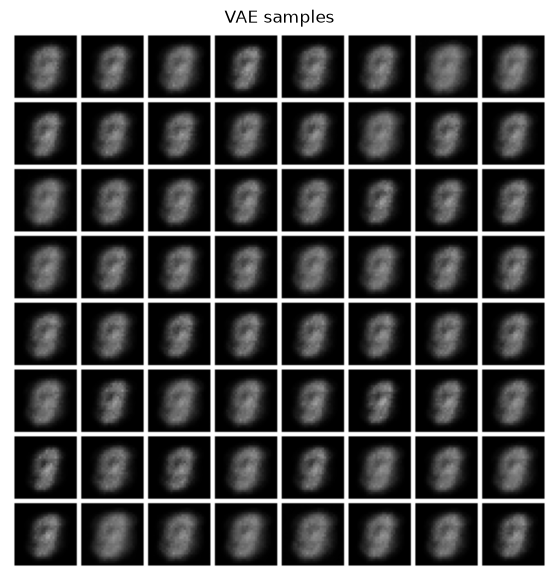

In [5]:
@torch.no_grad()
def show_vae_samples(model: VAE, n: int = 64) -> None:
    model.eval()
    z = torch.randn(n, 16, device=device)
    logits = model.decode_logits(z)
    imgs = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()
    grid = make_grid(imgs, nrow=8, pad_value=1.0)
    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title("VAE samples")
    plt.show()


show_vae_samples(vae)

## Section B - Simple GAN on MNIST

We implement a compact MLP-based GAN for educational clarity.

- Generator maps latent noise $z$ to image logits.
- Discriminator predicts whether an image is real or generated.

Training alternates between discriminator and generator updates.

In [6]:
LATENT_DIM = 64


class Generator(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.view(x.size(0), -1))

In [7]:
def train_gan(
    gen: Generator,
    disc: Discriminator,
    loader: DataLoader,
    epochs: int = 1,
    lr: float = 2e-4,
) -> list[dict[str, float]]:
    gen.to(device)
    disc.to(device)

    opt_g = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()
    history: list[dict[str, float]] = []

    for epoch in range(1, epochs + 1):
        g_loss_epoch = 0.0
        d_loss_epoch = 0.0
        steps = 0

        for x_real, _ in loader:
            x_real = x_real.to(device)
            x_real = x_real * 2.0 - 1.0
            bsz = x_real.size(0)

            real_targets = torch.ones(bsz, 1, device=device)
            fake_targets = torch.zeros(bsz, 1, device=device)

            z = torch.randn(bsz, LATENT_DIM, device=device)
            x_fake = gen(z)

            d_real = disc(x_real)
            d_fake = disc(x_fake.detach())
            d_loss = criterion(d_real, real_targets) + criterion(d_fake, fake_targets)

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            d_fake_for_g = disc(x_fake)
            g_loss = criterion(d_fake_for_g, real_targets)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()
            steps += 1

        history.append(
            {
                "epoch": float(epoch),
                "g_loss": g_loss_epoch / max(steps, 1),
                "d_loss": d_loss_epoch / max(steps, 1),
            }
        )

    return history


gen = Generator()
disc = Discriminator()
gan_history = train_gan(gen, disc, train_loader, epochs=1)
gan_history

[{'epoch': 1.0, 'g_loss': 0.6416082587093115, 'd_loss': 1.0367549136281013}]

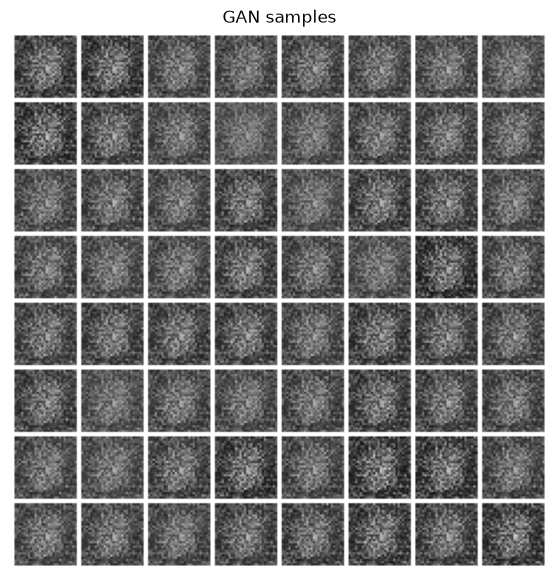

In [8]:
@torch.no_grad()
def show_gan_samples(gen: Generator, n: int = 64) -> None:
    gen.eval()
    z = torch.randn(n, LATENT_DIM, device=device)
    imgs = gen(z).cpu()
    imgs = (imgs + 1.0) / 2.0
    grid = make_grid(imgs, nrow=8, pad_value=1.0)
    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title("GAN samples")
    plt.show()


show_gan_samples(gen)

## Link to Theory

- VAE code reflects the ELBO decomposition into reconstruction + KL regularization.
- GAN code reflects adversarial optimization with alternating discriminator/generator steps.
- In practice, GAN instability often appears as oscillating losses or low sample diversity.
- If samples are blurry in the VAE, consider richer decoder architecture or alternative likelihoods.

## Business Case Studies & Exceptions

### Case 1: Synthetic Data for Fraud Model Development

- **Scenario**: a fintech team wants to share realistic transactions with vendors for prototyping.
- **Pattern**: train tabular VAE/flow, sample synthetic records, validate downstream utility and privacy risks.
- **Exception**: synthetic data can still leak sensitive patterns; always run linkage/privacy tests.

### Case 2: Quality Inspection Data Augmentation

- **Scenario**: few defect images in manufacturing.
- **Pattern**: use generative augmentation to increase rare defect variety.
- **Exception**: unrealistic artifacts can hurt real-world performance; evaluate on real-only holdout slices.

### Code Pattern (pseudo)

```python
synthetic_df = generator.sample(n=50_000)
auc_real = evaluate(real_holdout)
auc_aug = evaluate(real_plus_synthetic_train, real_holdout)
assert auc_aug >= auc_real - tolerance
```

## Interview Questions & Answers

1. **Q: What is a latent variable model?**
   **A:** A model where observed data is generated from hidden variables, usually integrated out in the marginal likelihood.

2. **Q: Why do VAEs use KL divergence?**
   **A:** To regularize approximate posterior latents toward a prior so sampling is coherent.

3. **Q: What does ELBO optimize?**
   **A:** A lower bound on log-likelihood balancing reconstruction quality and latent regularization.

4. **Q: What is mode collapse in GANs?**
   **A:** Generator produces low-diversity samples, often repeating similar outputs.

5. **Q: Why can GAN samples look sharper than VAE samples?**
   **A:** Adversarial objectives emphasize perceptual realism rather than pixel-wise averaging.

6. **Q: How do you stabilize GAN training?**
   **A:** Better objectives (e.g., Wasserstein variants), normalization constraints, balanced update schedules, careful tuning.

7. **Q: When would you choose a VAE over GAN?**
   **A:** When stable training and a structured latent space are more important than peak visual sharpness.

8. **Q: What is posterior collapse?**
   **A:** Decoder ignores latent signal and KL term forces posterior close to prior, reducing useful latent representation.

9. **Q: How do you evaluate synthetic data quality?**
   **A:** Statistical similarity, downstream utility, diversity/coverage, and privacy risk checks.

10. **Q: Can synthetic data replace real data entirely?**
   **A:** Usually no; it helps augmentation and prototyping, but final validation should use real representative data.

11. **Q: What is the generator objective in basic GAN training?**
   **A:** Fool discriminator into classifying generated samples as real.

12. **Q: What is a practical first generative baseline?**
   **A:** A small VAE for stable diagnostics, then move to adversarial/diffusion models if quality demands it.
